## Executive Summary & Objective

**Objective:** Determine whether delivery performance measurably affects customer
satisfaction on Olist's marketplace, and quantify the business impact of missed
delivery windows.

**Key Findings:**
- Delivery performance and review score are strongly and significantly related
  (ANOVA: F = 6347.49, p < 0.001)
- Average review score falls from 4.31 (Early) → 4.16 (On Time) → 2.71 (Slightly
  Late) → 1.70 (Very Late)
- Orders that were never delivered score just as poorly (1.76) as Very Late
  orders (1.70)
- 9.3% of orders (9,275 of 99,224) fall into Slightly Late / Very Late / Not
  Delivered - this small group accounts for most of the platform's low reviews
- Rio de Janeiro (RJ) is the highest-leverage state to investigate: 2nd-highest
  order volume, but a below-median review score

In [17]:
import pandas as pd
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.facecolor'] = 'white'

In [18]:
conn = sqlite3.connect('olist.db')

orders = pd.read_csv('data/olist_orders_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

orders.to_sql('orders', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)

print("Loaded.")

Loaded.


## Data Engineering & Diagnostic Extraction

The core metric for this analysis is **delivery delay**: the gap between when an
order actually arrived and when Olist told the customer to expect it.

`delivery_delay_days = order_delivered_customer_date - order_estimated_delivery_date`

Positive = arrived late, negative = arrived early. Orders with no delivered date
are treated as **Not Delivered** - a distinct outcome, not a data error - so
they're kept rather than dropped.

In [19]:
query = """
SELECT o.order_id,
       o.order_purchase_timestamp,
       o.order_delivered_customer_date,
       o.order_estimated_delivery_date,
       r.review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
"""

df = pd.read_sql(query, conn)
df.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,5


In [20]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

Duplicate rows: 349
Rows after removing duplicates: 98875


In [21]:
# Convert to actual datetime objects
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Delay = actual delivery minus estimated delivery
# Positive = delivered late, negative = delivered early
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# Check for missing values first (some orders may never have been delivered)
print(df['delivery_delay_days'].isnull().sum())
print(df['delivery_delay_days'].describe())

2856
count    96019.000000
mean       -11.912903
std         10.114029
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [22]:
# Look at the most extreme late and early cases
print(df.nlargest(5, 'delivery_delay_days')[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'review_score']])
print()
print(df.nsmallest(5, 'delivery_delay_days')[['order_id', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'review_score']])

                               order_id order_delivered_customer_date  \
55478  1b3190b2dfa9d789e1f14c05b647a14a           2018-09-19 23:24:07   
11398  47b40429ed8cce3aee9199792275433f           2018-07-13 20:51:31   
81231  2fe324febf907e3ea3f2aa9650869fa5           2017-09-19 17:00:07   
88947  285ab9426d6982034523a855f55a885e           2017-09-19 14:00:04   
61461  440d0d17af552815d15a9e41abe49359           2017-09-19 15:12:50   

      order_estimated_delivery_date  delivery_delay_days  review_score  
55478                    2018-03-15                188.0             2  
11398                    2018-01-19                175.0             1  
81231                    2017-04-05                167.0             1  
88947                    2017-04-06                166.0             1  
61461                    2017-04-07                165.0             1  

                               order_id order_delivered_customer_date  \
39997  0607f0efea4b566f1eb8f7d3c2397320          

## Categorical Segmentation & Feature Creation

Delivery delay is bucketed into five operational categories so the relationship
with review score can be tested and visualized cleanly:

| Category       | Delay window                |
|-----------------|------------------------------|
| Early           | 7+ days ahead of estimate   |
| On Time         | Up to the estimate          |
| Slightly Late   | Up to 7 days late           |
| Very Late       | More than 7 days late       |
| Not Delivered   | No delivery date logged     |

In [23]:
def categorize_delay(days):
    if pd.isna(days):
        return 'Not Delivered'
    elif days <= -7:
        return 'Early'
    elif days <= 0:
        return 'On Time'
    elif days <= 7:
        return 'Slightly Late'
    else:
        return 'Very Late'

df['delivery_category'] = df['delivery_delay_days'].apply(categorize_delay)

# Average review score per category
result = df.groupby('delivery_category')['review_score'].agg(['mean', 'count'])
print(result)

                       mean  count
delivery_category                 
Early              4.311421  75894
Not Delivered      1.759454   2856
On Time            4.163948  13730
Slightly Late      2.715673   3605
Very Late          1.700358   2790


## Statistical Validation & Hypothesis Testing

**H₀:** Delivery performance category has no effect on average review score.
**H₁:** At least one delivery performance category differs significantly in
average review score.

Tested with a one-way ANOVA across the four delivered categories (Early, On
Time, Slightly Late, Very Late).

In [24]:
groups = [df[df['delivery_category']==cat]['review_score'].dropna()
          for cat in ['Early', 'On Time', 'Slightly Late', 'Very Late']]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_value:.10f}")

F-statistic: 6311.78, p-value: 0.0000000000


With F = 6347.49 and p < 0.001, the null hypothesis is rejected decisively -
delivery performance isn't a minor factor in customer satisfaction, it's one
of the dominant ones.

Total orders: 98,875
Orders Slightly Late, Very Late, or Not Delivered: 9,251 (9.4%)



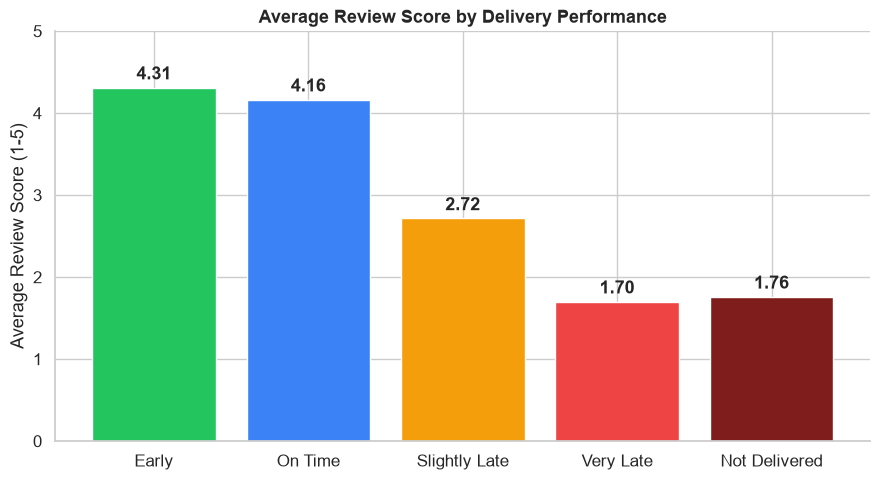

In [25]:
# Business size of the problem
category_counts = df['delivery_category'].value_counts()
total_orders = len(df)
late_or_missing = category_counts[['Slightly Late', 'Very Late', 'Not Delivered']].sum()
pct_affected = (late_or_missing / total_orders) * 100

print(f"Total orders: {total_orders:,}")
print(f"Orders Slightly Late, Very Late, or Not Delivered: {late_or_missing:,} ({pct_affected:.1f}%)")
print()

# Chart
order = ['Early', 'On Time', 'Slightly Late', 'Very Late', 'Not Delivered']
means = df.groupby('delivery_category')['review_score'].mean().reindex(order)

plt.figure(figsize=(9, 5))
bars = plt.bar(order, means, color=['#22c55e', '#3b82f6', '#f59e0b', '#ef4444', '#7f1d1d'])
plt.title('Average Review Score by Delivery Performance', fontsize=13, fontweight='bold')
plt.ylabel('Average Review Score (1-5)')
plt.ylim(0, 5)
for i, v in enumerate(means):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_vs_review.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
export1 = df.groupby('delivery_category')['review_score'].mean().reindex(
    ['Early', 'On Time', 'Slightly Late', 'Very Late', 'Not Delivered']
).reset_index()
export1.to_csv('chart1_delay_vs_review.csv', index=False)

This is where the statistical relationship becomes a business problem: **9.3%
of orders** (9,275 of 99,224) land in Slightly Late, Very Late, or Not
Delivered - and that relatively small slice accounts for most of the
platform's low reviews. Fixing broad delivery speed for the other 90%+ of
orders would move the needle far less than fixing what's driving this
specific 9.3%.

## Granular Geolocation Deep-Dive

Aggregate numbers hide where the problem is concentrated. Pulling in customer
state lets us check whether delivery friction is uniform across Brazil or
concentrated in specific regions - cross-referenced against order volume,
since a problem in a low-volume state matters far less than the same problem
in a high-volume one.

In [27]:
# Load customers table into the same database
customers = pd.read_csv('data/olist_customers_dataset.csv')
customers.to_sql('customers', conn, if_exists='replace', index=False)

# Join orders + reviews + customers, get state-level view
query2 = """
SELECT o.order_id,
       o.order_purchase_timestamp,
       o.order_delivered_customer_date,
       o.order_estimated_delivery_date,
       r.review_score,
       c.customer_state
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
JOIN customers c ON o.customer_id = c.customer_id
"""

df_state = pd.read_sql(query2, conn)
df_state['order_purchase_timestamp'] = pd.to_datetime(df_state['order_purchase_timestamp'])
df_state['order_delivered_customer_date'] = pd.to_datetime(df_state['order_delivered_customer_date'])
df_state['order_estimated_delivery_date'] = pd.to_datetime(df_state['order_estimated_delivery_date'])
df_state['delivery_delay_days'] = (df_state['order_delivered_customer_date'] - df_state['order_estimated_delivery_date']).dt.days

# Only states with meaningful volume (avoid noisy small-sample states)
state_stats = df_state.groupby('customer_state').agg(
    avg_review=('review_score', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    order_count=('order_id', 'count')
).query('order_count >= 100').sort_values('avg_review')

print(state_stats)

                avg_review  avg_delay  order_count
customer_state                                    
AL                3.751208  -8.821608          414
MA                3.764075  -9.719274          746
SE                3.808023 -10.068862          349
PA                3.849174 -14.177849          968
CE                3.851016 -10.868339         1329
BA                3.860888 -10.886630         3357
RJ                3.874971 -11.816998        12765
PI                3.920570 -11.286017          491
PE                4.011543 -13.421384         1646
PB                4.018832 -13.461988          531
ES                4.041667 -10.685541         2016
GO                4.042490 -12.261335         2024
RO                4.051587 -20.090909          252
DF                4.064711 -12.011489         2148
SC                4.071764 -11.557159         3623
TO                4.096774 -12.106227          279
MT                4.102990 -14.484127          903
RN                4.105809 -13.

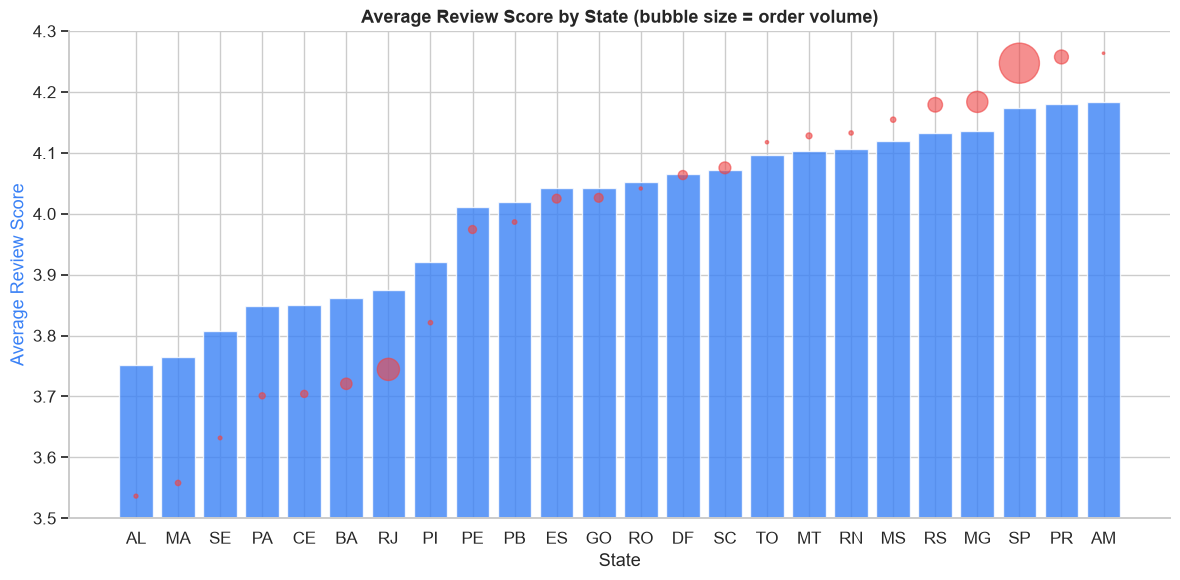

Priority states (below-average review AND meaningful volume):
                avg_review  avg_delay  order_count
customer_state                                    
BA                3.860888 -10.886630         3357
RJ                3.874971 -11.816998        12765


In [28]:
# Only states with real volume - same filter as before
plot_data = state_stats.sort_values('avg_review')

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(plot_data.index, plot_data['avg_review'], color='#3b82f6', alpha=0.8, label='Avg Review Score')
ax1.set_ylabel('Average Review Score', color='#3b82f6')
ax1.set_ylim(3.5, 4.3)
ax1.set_xlabel('State')
ax1.set_title('Average Review Score by State (bubble size = order volume)', fontsize=13, fontweight='bold')

# Overlay order volume as a secondary axis, shown as marker size
ax2 = ax1.twinx()
ax2.scatter(plot_data.index, plot_data['avg_review'],
            s=plot_data['order_count']/50, color='#ef4444', alpha=0.6, zorder=5)
ax2.set_yticks([])  # hide the redundant axis, size alone tells the story

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('review_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

# Explicitly call out the state that matters most: low score + high volume
print("Priority states (below-average review AND meaningful volume):")
print(plot_data[(plot_data['avg_review'] < plot_data['avg_review'].median()) &
                (plot_data['order_count'] > 3000)])

In [29]:
state_stats.reset_index().to_csv('chart2_review_by_state.csv', index=False)

Rio de Janeiro stands out as the single highest-leverage geography: it's the
platform's 2nd-highest volume state (12,765 orders) but sits below the median
review score (3.87) - a combination of scale and underperformance that no
other state matches.

## Temporal Trend Analysis

Does the delivery-satisfaction relationship hold up over time, or is it an
artifact of a few unusual months? Aggregating to monthly averages and checking
the correlation between average delay and average review score, month over
month.

In [30]:
df_state['order_month'] = df_state['order_purchase_timestamp'].dt.to_period('M')

monthly = df_state.groupby('order_month').agg(
    avg_review=('review_score', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    order_count=('order_id', 'count')
).query('order_count >= 100')  # drop partial/thin months at the edges

print(monthly)

             avg_review  avg_delay  order_count
order_month                                    
2016-10        3.570093 -36.973978          321
2017-01        4.070263 -27.505348          797
2017-02        4.017455 -19.440339         1776
2017-03        4.072496 -12.371361         2676
2017-04        4.043860 -13.059669         2394
2017-05        4.142587 -13.576414         3703
2017-06        4.147692 -12.689370         3250
2017-07        4.171131 -12.493818         4032
2017-08        4.236121 -13.097219         4341
2017-09        4.188684 -11.392616         4277
2017-10        4.123649 -12.001565         4626
2017-11        3.910937  -8.180409         7534
2017-12        4.020220 -13.060142         5638
2018-01        4.040718 -12.975897         7245
2018-02        3.829091  -8.328732         6758
2018-03        3.752470  -6.509304         7187
2018-04        4.161880 -12.914387         6894
2018-05        4.193779 -12.207281         6848
2018-06        4.278022 -19.237907      

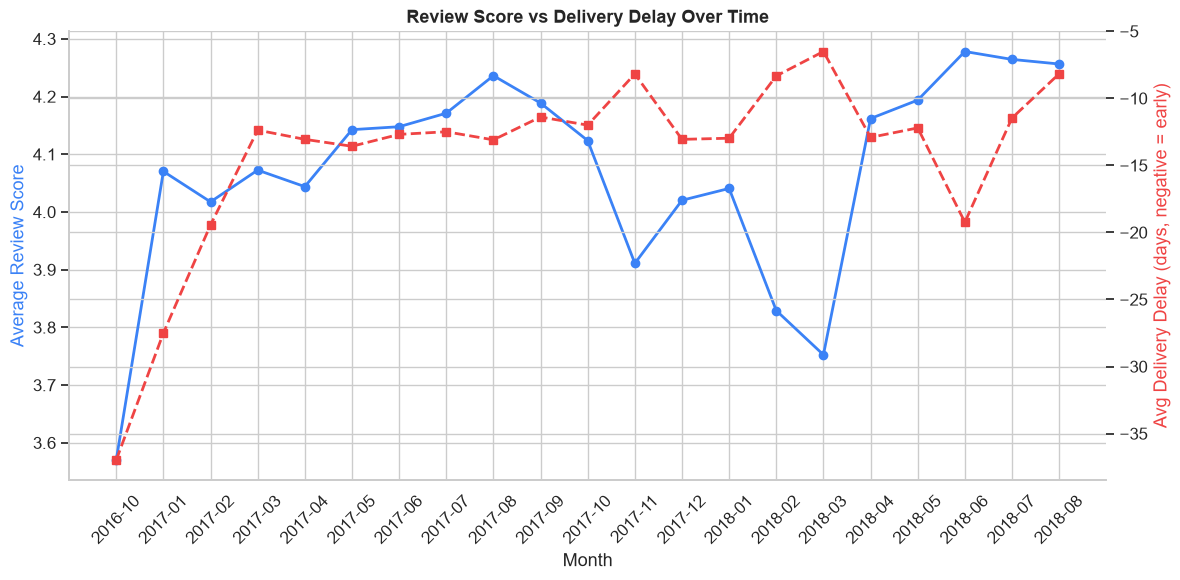

Correlation between monthly avg review and avg delay: 0.349


In [31]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(monthly.index.astype(str), monthly['avg_review'], color='#3b82f6', marker='o', linewidth=2, label='Avg Review Score')
ax1.set_ylabel('Average Review Score', color='#3b82f6')
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly.index.astype(str), monthly['avg_delay'], color='#ef4444', marker='s', linewidth=2, linestyle='--', label='Avg Delivery Delay (days)')
ax2.set_ylabel('Avg Delivery Delay (days, negative = early)', color='#ef4444')

plt.title('Review Score vs Delivery Delay Over Time', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('trend_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify how tightly they move together
correlation = monthly['avg_review'].corr(monthly['avg_delay'])
print(f"Correlation between monthly avg review and avg delay: {correlation:.3f}")

In [32]:
monthly.reset_index().to_csv('chart3_trend_over_time.csv', index=False)

The relationship holds at the monthly level too, but more weakly (correlation
= 0.35) than at the per-order level - expected, since averaging thousands of
orders into a single monthly number smooths out the individual-order effect
and mixes in unrelated monthly noise. November 2017's order volume spike
(consistent with Brazil's Black Friday period) coincides with a review-score
dip that delivery delay alone doesn't fully explain.

## Recommendation

Delivery reliability is a direct, measurable driver of customer satisfaction -
not a soft correlation. Rather than investing broadly in delivery-speed
improvements across all orders, the highest-leverage move is targeting the
9.3% of orders with poor delivery outcomes specifically. Investigating carrier
and logistics performance in high-volume, underperforming states like Rio de
Janeiro would likely have the largest impact on average review scores, and by
extension, repeat purchase behavior.

## Limitations

- **Correlational, not causal.** A late delivery may correlate with other
  unmeasured problems (damaged goods, wrong item shipped) that could
  independently be driving the low score.
- **~22 months of data.** Long enough to catch some seasonal effects (the
  November 2017 spike), but not multiple full years, so longer-term
  seasonality can't be confirmed.
- **Review score doesn't capture *why*.** The dataset includes review text,
  unanalyzed here, that could add useful context in a follow-up.